In [1]:
import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("homeprices.csv")
df.head()

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


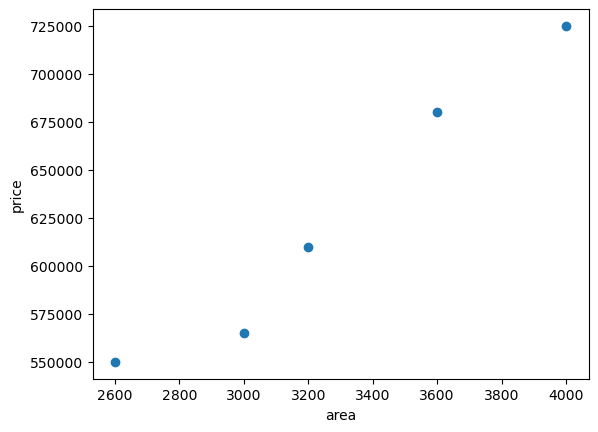

In [4]:
plt.xlabel("area")
plt.ylabel("price")
plt.scatter(df.area,df.price)

In [7]:
area=df.drop("price",axis="columns")
area

,area
0,2600
1,3000
2,3200
3,3600
4,4000


In [8]:
price=df.price
price

0    550000
1    565000
2    610000
3    680000
4    725000
Name: price, dtype: int64

In [9]:

model=linear_model.LinearRegression()
model.fit(area,price)

LinearRegression()

In [10]:
model.coef_

array([135.78767123])

In [11]:
model.intercept_

180616.43835616432

In [17]:
new_data=pd.DataFrame([[3500]],columns=['area'])
pred=model.predict(new_data)
final_pred=np.round(pred,2)
final_pred

array([655873.29])

In [18]:
p=model.predict(df[['area']])
p=np.round(p,2)
p

array([533664.38, 587979.45, 615136.99, 669452.05, 723767.12])

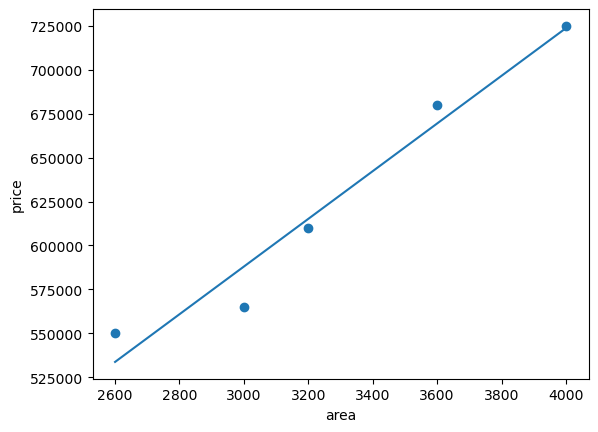

In [19]:
plt.xlabel("area")
plt.ylabel("price")
plt.scatter(df.area,df.price)
plt.plot(df.area,model.predict(df[['area']]))

In [20]:
model.score(df[['area']],df.price)

0.9584301138199486

In [21]:
#give me prediction for area=6500 and 10000
135.78767123*6500+180616.43835616432

1063236.3013511642

In [23]:
data=pd.read_csv("areas.csv")
data.head()

,area
0,1000
1,1500
2,2300
3,3540
4,4120


In [24]:
pred=model.predict(data)
pred=np.round(pred,2)
pred

array([ 316404.11,  384297.95,  492928.08,  661304.79,  740061.64,
        799808.22,  926090.75,  650441.78,  825607.88,  492928.08,
       1402705.48, 1348390.41, 1144708.9 ])

In [26]:
data['predicted_price']=pred
data.head()

,area,predicted_price
0,1000,316404.11
1,1500,384297.95
2,2300,492928.08
3,3540,661304.79
4,4120,740061.64


In [32]:
data.to_csv("predicted_price.csv", index=False)